# Case Study: Cryptomnesia — Unconscious Plagiarism in a DRM Dialogue
### Hierarchical Bayesian logistic regression with crossed random effects

*Based on:* Gershkovich V.A. & Popova A.S. (2017), CogSci-adjacent diploma research
(Popova, 2017, SPbSU) + three replication samples; Bayesian reanalysis developed in the
Gershkovich lab (PyMC 5). Data: `AllData` → cleaned `data_cleaned.csv`, **8,350 trials,
159 participants, 4 experiments**.

**The phenomenon.** In cryptoamnesia ("unconscious plagiarism") people mistakenly claim
*other people's* ideas as their own — famously suspected when Poincaré and Darwin worried about
independently rediscovering someone's published idea (Newton & Newton, 1980). Here the laboratory
analogue uses the **DRM paradigm** (Deese–Roediger–McDermott): studying associates of a missing
critical word (море, гора, книга, сон, стул) makes the critical word *feel* familiar later.

**The experiment.** Participants took turns reading words aloud with a virtual partner ("Misha").
At test, every word — theirs, the partner's, and never-presented DRM critical lures — required one
binary judgement: **"Did I say this, or did Misha?"**

**The modelling questions:**
1. Are DRM lures attributed to *oneself* more than the partner's ordinary words? (cryptomnesia)
2. Does a one-week delay amplify it? Does partner verbalization of the lure change it?
3. Does the word's **association strength** (LogDice to the critical word) predict erroneous
   self-attribution — i.e., is the mechanism *familiarity-through-association*?
4. Do response times carry an independent signal?

**What you will learn:** crossed random effects (participant × list × experiment) in logistic
regression; treatment coding with probability-scale contrasts; directional posterior probabilities
as evidence (including evidence *for* null effects); a continuous stimulus property (LogDice)
interacting with source; and a hierarchical log-RT model on the same stimulus classes.

**Running on Colab?** Execute the next cell once to download the data files.

In [ ]:
import os
if not os.path.exists("data/cryptomnesia"):
!wget -q -P data/cryptomnesia https://raw.githubusercontent.com/iknyazeva/bayes-cogsci-book/main/case_studies/data/cryptomnesia/data_cleaned.csv

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import json
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

print("pymc:", pm.__version__, "| arviz:", az.__version__, "| pandas:", pd.__version__)
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

DATA_DIR = "data/cryptomnesia"
FIG_DIR = "figures"
import os
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(fig, name):
    fig.savefig(f"{FIG_DIR}/{name}", dpi=150, bbox_inches="tight")
    print("saved:", f"{FIG_DIR}/{name}")

pymc: 5.28.0 | arviz: 0.23.4 | pandas: 3.0.2


## 1. Design & data

Four experiments contribute participants; between-subject factors are the **retention interval**
(immediate vs 1 week) and whether the partner **verbalized** the critical lure during the dialogue:

| Experiment | N | Interval | Verbalization |
|---|---|---|---|
| Попова_д (original diploma, 4 groups × 20) | 80 | 0 & 1 | 0 & 1 |
| Попова_к (replication) | 40 | 0 & 1 | 0 |
| бурлан_д | 19 | 1 | 1 |
| лг_доп | 20 | 0 | 1 |

Every trial is one word with its source and the participant's attribution. We aggregate the
8,350 trials into **six stimulus classes** — the cross of {ordinary partner, ordinary self,
critical DRM} × {no verbalization, verbalization}:

| # | stimulus_class | meaning |
|---|---|---|
| 0 | `ordinary_partner_noverb` | partner's word, lure never spoken — **reference class** |
| 1 | `ordinary_self_noverb` | own word, lure never spoken |
| 2 | `critical_unpresented` | DRM lure, never presented by anyone |
| 3 | `ordinary_partner_verb` | partner's word, partner said the lure aloud |
| 4 | `ordinary_self_verb` | own word, lure spoken |
| 5 | `critical_partner` | the DRM lure itself, spoken by the partner |

*(The lab's `models_improved.py` uses exactly this coding.)*

In [2]:
df = pd.read_csv(f"{DATA_DIR}/data_cleaned.csv")
df["is_drm"] = (df["stim_code"] == 2).astype(int)
df["source_type"] = df["source_code"].map({0: "partner", 1: "self", 2: "drm"})

CLASS_ORDER = ["ordinary_partner_noverb", "ordinary_self_noverb", "critical_unpresented",
               "ordinary_partner_verb", "ordinary_self_verb", "critical_partner"]
df["stimulus_class"] = np.select(
    [(df.is_drm == 0) & (df.source_type == "partner") & (df.verbalization == 0),
     (df.is_drm == 0) & (df.source_type == "self") & (df.verbalization == 0),
     (df.is_drm == 1) & (df.verbalization == 0),
     (df.is_drm == 0) & (df.source_type == "partner") & (df.verbalization == 1),
     (df.is_drm == 0) & (df.source_type == "self") & (df.verbalization == 1),
     (df.is_drm == 1) & (df.verbalization == 1)],
    CLASS_ORDER, default="unknown")

d = df[df.stimulus_class != "unknown"].copy()
d["class_idx"] = pd.Categorical(d.stimulus_class, categories=CLASS_ORDER, ordered=True).codes
CLASS_SHORT = ["partner\nnoverb", "self\nnoverb", "DRM\nunpresented",
               "partner\nverb", "self\nverb", "DRM\npartner"]
print(f"attribution analysis: {len(d)} trials, {d.participant_id.nunique()} participants")
d.groupby(["stimulus_class", "interval"]).response.agg(["count", "mean"]).round(3)

attribution analysis: 8350 trials, 159 participants


count   mean
stimulus_class          interval              
critical_partner        0           200  0.630
                        1           195  0.610
critical_unpresented    0           200  0.465
                        1           200  0.660
ordinary_partner_noverb 0          1000  0.301
                        1          1000  0.456
ordinary_partner_verb   0           800  0.268
                        1           780  0.429
ordinary_self_noverb    0          1000  0.626
                        1          1000  0.496
ordinary_self_verb      0          1000  0.634
                        1           975  0.441

saved: figures/attribution_by_class.png


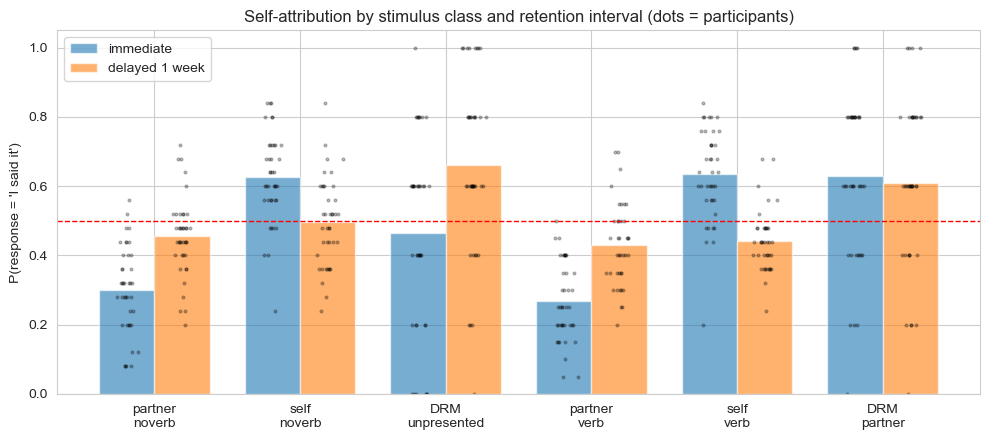

In [3]:
# ---- descriptive figure: P(response = "self") by class x interval ----
agg = (d.groupby(["stimulus_class", "interval", "participant_id"]).response.mean()
        .reset_index())
cell_means = agg.groupby(["stimulus_class", "interval"]).response.mean()

fig, ax = plt.subplots(figsize=(10, 4.5))
width = 0.38
for k, cls in enumerate(CLASS_ORDER):
    for ivl, color, off in [(0, "tab:blue", -width/2), (1, "tab:orange", width/2)]:
        sub = agg[(agg.stimulus_class == cls) & (agg.interval == ivl)]
        pos = k + off
        ax.bar(pos, cell_means[cls, ivl], width=width, alpha=0.6, color=color,
               label="immediate" if (k == 0 and ivl == 0) else ("delayed 1 week" if (k == 0 and ivl == 1) else None))
        xj = rng.normal(pos, 0.035, len(sub))
        ax.plot(xj, sub.response, "k.", alpha=0.25, markersize=4)
ax.axhline(0.5, color="red", ls="--", lw=1)
ax.set_xticks(range(6), CLASS_SHORT)
ax.set_ylabel("P(response = 'I said it')")
ax.set_title("Self-attribution by stimulus class and retention interval (dots = participants)")
ax.legend()
fig.tight_layout()
save_fig(fig, "attribution_by_class.png")
plt.show()

**Raw data already tells the story.** Own words are correctly claimed (~0.6–0.8), the partner's
words are mostly denied (~0.3–0.45, rising with delay). The two DRM classes — words *nobody ever
said* — sit in between and climb with delay. But how confidently can we compare classes, given that
each participant contributes many trials, lists differ, and experiments were run at different
times? That is exactly what the hierarchical model formalizes.

## 2. Model 1 — unified attribution model

One hierarchical logistic regression over all six classes and both intervals:

$$y_i \sim \operatorname{Bernoulli}(p_i), \qquad
\operatorname{logit}(p_i) = \underbrace{\alpha_{j[i]} + \delta_{m[i]} + \gamma_{e[i]}}_{\text{crossed random intercepts}}
+ \beta_t\, t_i + \sum_{k=1}^{5} \beta_k u_{ik} + \sum_{k=1}^{5} \omega_k u_{ik} t_i$$

* $u_{ik}$: treatment dummies for the five non-reference classes (reference = `ordinary_partner_noverb`);
* $t_i$: interval (0 immediate, 1 delayed);
* $\beta_k + \omega_k$: class offsets and class-specific delay effects;
* **three crossed random intercepts**: participant $\alpha_j$ (159), DRM list $\delta_m$ (5),
  experiment $\gamma_e$ (4) — all non-centered.

Why crossed effects? Trials nest in participants, but *also* in word lists (море vs стул differ in
lure strength) and in experiments (replications ran in different years/instructions). Ignoring any
of these pseudoreplicates would inflate confidence.

In [4]:
def prep_re(dfx):
    pidx, pids = pd.factorize(dfx["participant_id"])
    lidx, lists = pd.factorize(dfx["list_num"])
    emap = {"Попова_д": 0, "Попова_к": 1, "бурлан_д": 2, "лг_доп": 3}
    eidx = dfx["experiment"].map(emap).values
    p2e = dfx.drop_duplicates("participant_id")["experiment"].map(emap).values
    return pidx, lidx, eidx, len(pids), len(lists), len(emap), p2e

def add_crossed_re(n_p, n_l, n_e):
    mu_alpha = pm.Normal("mu_alpha", 0, 1.5)
    sigma_alpha = pm.HalfNormal("sigma_alpha", 1)
    z_alpha = pm.Normal("z_alpha", 0, 1, shape=n_p)
    sigma_list = pm.HalfNormal("sigma_list", 0.5)
    z_list = pm.Normal("z_list", 0, 1, shape=n_l)
    sigma_exp = pm.HalfNormal("sigma_exp", 0.5)
    z_exp = pm.Normal("z_exp", 0, 1, shape=n_e)
    return (mu_alpha,
            mu_alpha + sigma_alpha * z_alpha,
            sigma_list * z_list,
            sigma_exp * z_exp)

pidx, lidx, eidx, n_p, n_l, n_e, p2e = prep_re(d)
n_classes = len(CLASS_ORDER)
X = np.eye(n_classes - 1)[np.clip(d.class_idx.values - 1, 0, n_classes - 2)]
X[d.class_idx.values == 0] = 0.0          # treatment coding, class 0 = reference
interval = d["interval"].values.astype(float)
response = d["response"].values.astype(int)

coords = {"class": CLASS_ORDER[1:], "obs_id": np.arange(len(d))}
with pm.Model(coords=coords) as m1:
    mu_alpha, alpha, delta, gamma = add_crossed_re(n_p, n_l, n_e)
    beta_interval = pm.Normal("beta_interval", 0, 1)
    beta_class = pm.Normal("beta_class", 0, 1.5, dims="class")
    beta_class_interval = pm.Normal("beta_class_interval", 0, 1, dims="class")

    logit_p = (alpha[pidx] + delta[lidx] + gamma[p2e[pidx]]
               + beta_interval * interval
               + pm.math.dot(X, beta_class) + pm.math.dot(X, beta_class_interval) * interval)
    pm.Bernoulli("y", logit_p=logit_p, observed=response, dims="obs_id")

    # probability-scale cells for interpretation
    beta_class_full = pm.math.concatenate([np.zeros(1), beta_class])
    beta_ci_full = pm.math.concatenate([np.zeros(1), beta_class_interval])
    for k, cls in enumerate(CLASS_ORDER):
        imm = pm.math.sigmoid(mu_alpha + beta_class_full[k])
        dly = pm.math.sigmoid(mu_alpha + beta_interval + beta_class_full[k] + beta_ci_full[k])
        pm.Deterministic(f"p_{cls}_immediate", imm)
        pm.Deterministic(f"p_{cls}_delayed", dly)

    idata_m1 = pm.sample(draws=1500, tune=1500, chains=4, target_accept=0.97,
                         idata_kwargs={"log_likelihood": True}, random_seed=RANDOM_SEED)

key = ["mu_alpha", "beta_interval", "beta_class", "beta_class_interval",
       "sigma_alpha", "sigma_list", "sigma_exp"]
print("max rhat:", float(az.rhat(idata_m1, var_names=key).to_array().max()))
print("divergences:", int(idata_m1.sample_stats.diverging.sum()))

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu_alpha, sigma_alpha, z_alpha, sigma_list, z_list, sigma_exp, z_exp, beta_interval, beta_class, beta_class_interval]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 80 seconds.


There were 7 divergences after tuning. Increase `target_accept` or reparameterize.


max rhat: 1.0055981509984062
divergences: 7


In [5]:
# ---- posterior probability cells ----
P_VARS = [f"p_{c}_{t}" for c in CLASS_ORDER for t in ["immediate", "delayed"]]
s = az.summary(idata_m1, var_names=P_VARS, kind="stats", hdi_prob=0.94)
s.index = [f"{c.replace('ordinary_', '').replace('_', ' ')} | {'imm' if t=='immediate' else 'delay'}"
           for c in CLASS_ORDER for t in ["immediate", "delayed"]]
s.round(3)

,mean,sd,hdi_3%,hdi_97%
partner noverb | imm,0.307,0.020,0.269,0.343
partner noverb | delay,0.452,0.023,0.410,0.495
self noverb | imm,0.626,0.022,0.584,0.665
self noverb | delay,0.497,0.022,0.453,0.538
critical unpresented | imm,0.466,0.038,0.393,0.536
critical unpresented | delay,0.660,0.036,0.594,0.729
partner verb | imm,0.265,0.020,0.226,0.301
partner verb | delay,0.428,0.024,0.381,0.471
self verb | imm,0.630,0.021,0.588,0.667
self verb | delay,0.441,0.023,0.400,0.484


saved: figures/p_by_class.png


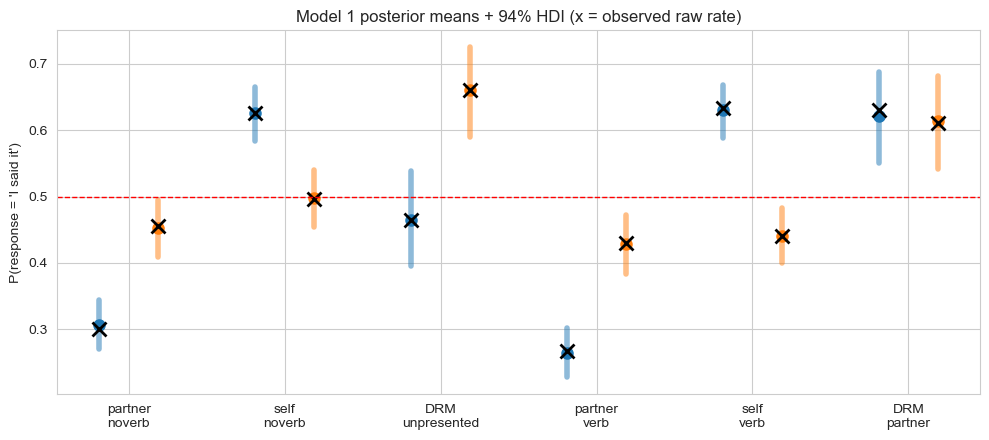

In [6]:
# ---- figure: posterior cell probabilities ----
fig, ax = plt.subplots(figsize=(10, 4.5))
pos, labels = [], []
for k, cls in enumerate(CLASS_ORDER):
    for t, color in [("immediate", "tab:blue"), ("delayed", "tab:orange")]:
        v = idata_m1.posterior[f"p_{cls}_{t}"].values.flatten()
        xx = k + (-0.19 if t == "immediate" else 0.19)
        lo, hi = np.quantile(v, [0.03, 0.97])
        ax.plot([xx, xx], [lo, hi], color=color, lw=4, alpha=0.5)
        ax.plot(xx, np.median(v), "o", color=color, ms=8)
        obs = d[(d.stimulus_class == cls) & (d.interval == (0 if t == "immediate" else 1))].response.mean()
        ax.plot(xx, obs, "kx", ms=10, mew=2)
    pos += [k]; labels += [CLASS_SHORT[k]]
ax.set_xticks(pos, labels)
ax.axhline(0.5, color="red", ls="--", lw=1)
ax.set_ylabel("P(response = 'I said it')")
ax.set_title("Model 1 posterior means + 94% HDI (x = observed raw rate)")
fig.tight_layout()
save_fig(fig, "p_by_class.png")
plt.show()

### 2.1 The cryptomnesia contrasts

The scientific claims live in *differences of probabilities*. We compute them directly from the
posterior of the cell probabilities:

* **C1** `critical_unpresented − ordinary_partner_noverb` (immediate): is an never-said DRM word
  already claimed more than the partner's real words?
* **C2** same, delayed: does a week amplify it?
* **C3** `critical_unpresented − ordinary_self_noverb` (delayed): the strong claim — after a week
  the lure is claimed even *more* than one's own real words.
* **C4** `critical_partner − ordinary_partner_verb`: even when Misha actually *said the lure aloud*,
  is it still claimed as one's own?

In [7]:
post = idata_m1.posterior.stack(s=("chain", "draw"))
def cell(cls, t):
    return post[f"p_{cls}_{t}"].values

contrasts = {
    "C1 DRM unpresented vs partner (imm)": cell("critical_unpresented", "immediate") - cell("ordinary_partner_noverb", "immediate"),
    "C2 DRM unpresented vs partner (delay)": cell("critical_unpresented", "delayed") - cell("ordinary_partner_noverb", "delayed"),
    "C3 DRM unpresented vs SELF (imm)": cell("critical_unpresented", "immediate") - cell("ordinary_self_noverb", "immediate"),
    "C3 DRM unpresented vs SELF (delay)": cell("critical_unpresented", "delayed") - cell("ordinary_self_noverb", "delayed"),
    "C4 DRM partner vs partner_verb (imm)": cell("critical_partner", "immediate") - cell("ordinary_partner_verb", "immediate"),
    "C4 DRM partner vs partner_verb (delay)": cell("critical_partner", "delayed") - cell("ordinary_partner_verb", "delayed"),
}
rows = []
for name, v in contrasts.items():
    lo, hi = np.quantile(v, [0.03, 0.97])
    rows.append({"contrast": name, "mean": v.mean(), "hdi3": lo, "hdi97": hi, "P(>0)": (v > 0).mean()})
pd.DataFrame(rows).round(3)

,contrast,mean,hdi3,hdi97,P(>0)
0,C1 DRM unpresented vs partner (imm),0.159,0.090,0.229,1.0
1,C2 DRM unpresented vs partner (delay),0.208,0.139,0.273,1.0
2,C3 DRM unpresented vs SELF (imm),-0.160,-0.232,-0.087,0.0
3,C3 DRM unpresented vs SELF (delay),0.163,0.093,0.228,1.0
4,C4 DRM partner vs partner_verb (imm),0.356,0.285,0.424,1.0
5,C4 DRM partner vs partner_verb (delay),0.185,0.113,0.257,1.0


### 2.2 Posterior predictive check

Simulate fresh datasets from the posterior and compare predicted vs observed self-attribution rates
per cell — if the model is adequate, points should scatter around the diagonal.

Sampling: [y]


Output()

saved: figures/ppc_calibration.png


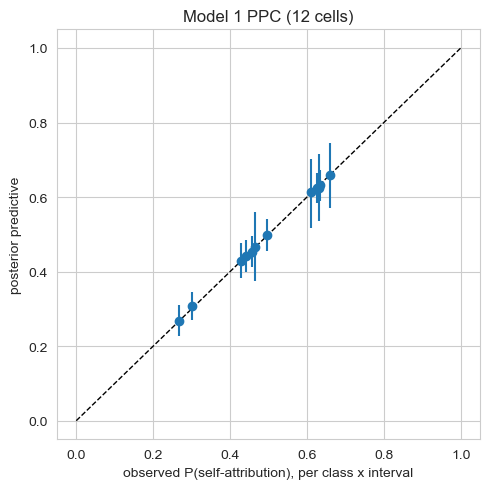

In [8]:
with m1:
    ppc = pm.sample_posterior_predictive(idata_m1, var_names=["y"], random_seed=RANDOM_SEED,
                                         extend_inferencedata=True)
_ppc_arr = ppc.posterior_predictive["y"].stack(s=("chain", "draw"))
_obs_dim = [d for d in _ppc_arr.dims if d != "s"][0]
ppc_draws = _ppc_arr.transpose("s", _obs_dim).values              # (S, obs)

cell_key = d.stimulus_class.values + "_" + d.interval.astype(str)
cells = np.unique(cell_key)
pred_rate, obs_rate, lo, hi = [], [], [], []
draws_cell = np.zeros((ppc_draws.shape[0], len(cells)))
for k, c in enumerate(cells):
    draws_cell[:, k] = ppc_draws[:, cell_key == c].mean(axis=1)
    obs_rate.append(d.response.values[cell_key == c].mean())
pred_rate = draws_cell.mean(axis=0)
lo = np.quantile(draws_cell, 0.03, axis=0)
hi = np.quantile(draws_cell, 0.97, axis=0)

fig, ax = plt.subplots(figsize=(5, 5))
ax.errorbar(obs_rate, pred_rate, yerr=[pred_rate - lo, hi - pred_rate], fmt="o", ms=6)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("observed P(self-attribution), per class x interval")
ax.set_ylabel("posterior predictive")
ax.set_title("Model 1 PPC (12 cells)")
fig.tight_layout()
save_fig(fig, "ppc_calibration.png")
plt.show()

## 3. Model 2 — association strength (LogDice) and source

If cryptomnesia is *familiarity-through-association*, then the stronger a word's association to the
critical lure (LogDice from a large Russian co-occurrence corpus), the more likely it should be
erroneously claimed — especially for the **partner's** words (one's own words are already claimed,
ceiling). This model is fitted to ordinary stimuli only, keeping the lab's full factorial
`actual_self × interval × verbalization` structure and adding

$$\operatorname{logit}(p_i) = (\ldots) + \beta_{ld}\, l_i + \beta_{ld \times self}\, s_i\, l_i$$

with $l_i$ = standardized LogDice and $s_i$ = word was one's own. The interpretable slopes are
`beta_logdice_partner = β_ld` and `beta_logdice_self = β_ld + β_ld×self`.

In [9]:
dl = df[(df.is_drm == 0) & df.logdice.notna()].copy()
dl["actual_self"] = (dl.source_type == "self").astype(int)
dl["logdice_z"] = (dl.logdice - dl.logdice.mean()) / dl.logdice.std()
pidx, lidx, eidx, n_p, n_l, n_e, p2e = prep_re(dl)

aself = dl.actual_self.values.astype(float)
ivl = dl.interval.values.astype(float)
verb = dl.verbalization.values.astype(float)
ldz = dl.logdice_z.values.astype(float)
resp = dl.response.values.astype(int)
print(f"LogDice analysis: {len(dl)} trials")

with pm.Model() as m2:
    mu_alpha, alpha, delta, gamma = add_crossed_re(n_p, n_l, n_e)
    beta_self = pm.Normal("beta_self", 0, 1.5)
    beta_interval = pm.Normal("beta_interval", 0, 1)
    beta_verbalization = pm.Normal("beta_verbalization", 0, 1)
    beta_self_interval = pm.Normal("beta_self_interval", 0, 1)
    beta_self_verbalization = pm.Normal("beta_self_verbalization", 0, 1)
    beta_interval_verbalization = pm.Normal("beta_interval_verbalization", 0, 1)
    beta_three_way = pm.Normal("beta_self_interval_verbalization", 0, 1)
    beta_logdice = pm.Normal("beta_logdice", 0, 1)
    beta_self_logdice = pm.Normal("beta_self_logdice", 0, 1)

    logit_p = (alpha[pidx] + delta[lidx] + gamma[p2e[pidx]]
               + beta_self * aself + beta_interval * ivl + beta_verbalization * verb
               + beta_self_interval * aself * ivl + beta_self_verbalization * aself * verb
               + beta_interval_verbalization * ivl * verb + beta_three_way * aself * ivl * verb
               + beta_logdice * ldz + beta_self_logdice * aself * ldz)
    pm.Bernoulli("y", logit_p=logit_p, observed=resp)
    pm.Deterministic("beta_logdice_partner", beta_logdice)
    pm.Deterministic("beta_logdice_self", beta_logdice + beta_self_logdice)

    idata_m2 = pm.sample(draws=1500, tune=1500, chains=4, target_accept=0.97,
                         idata_kwargs={"log_likelihood": True}, random_seed=RANDOM_SEED)

az.summary(idata_m2, var_names=["beta_self", "beta_logdice_partner", "beta_self_logdice",
                                "beta_logdice_self"], kind="stats", hdi_prob=0.94).round(3)

LogDice analysis: 7475 trials


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu_alpha, sigma_alpha, z_alpha, sigma_list, z_list, sigma_exp, z_exp, beta_self, beta_interval, beta_verbalization, beta_self_interval, beta_self_verbalization, beta_interval_verbalization, beta_self_interval_verbalization, beta_logdice, beta_self_logdice]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 126 seconds.


There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


,mean,sd,hdi_3%,hdi_97%
beta_self,1.335,0.093,1.161,1.511
beta_logdice_partner,0.153,0.039,0.081,0.225
beta_self_logdice,-0.128,0.050,-0.219,-0.031
beta_logdice_self,0.025,0.034,-0.039,0.089


saved: figures/logdice_effect.png


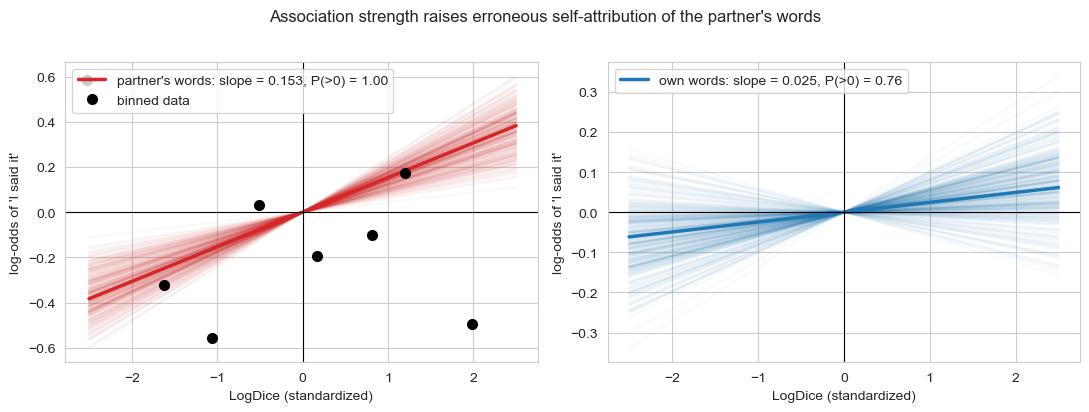

In [10]:
# ---- LogDice effect figure ----
p2 = idata_m2.posterior
grid = np.linspace(-2.5, 2.5, 100)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (var, color, name) in zip(axes, [("beta_logdice_partner", "tab:red", "partner's words"),
                                         ("beta_logdice_self", "tab:blue", "own words")]):
    slopes = p2[var].stack(s=("chain", "draw")).values
    lines = slopes[::20, None] * grid[None, :]
    ax.plot(grid, lines.T, color=color, alpha=0.03)
    ax.plot(grid, slopes.mean() * grid, color=color, lw=2.5,
            label=f"{name}: slope = {slopes.mean():.3f}, P(>0) = {(slopes>0).mean():.2f}")
    ax.set_xlabel("LogDice (standardized)")
    ax.set_ylabel("log-odds of 'I said it'")
    ax.axhline(0, color="k", lw=0.8); ax.axvline(0, color="k", lw=0.8)
    ax.legend(loc="upper left")

# overlay binned raw rates
bins = pd.cut(dl.logdice_z, 8)
binned = dl.groupby(bins, observed=True).agg(x=("logdice_z", "mean"), y=("response", "mean"))
axes[0].plot(binned.x, np.log((binned.y + .02) / (1 - binned.y + .02)), "ko", ms=7, label="binned data")
axes[0].legend(loc="upper left")
fig.suptitle("Association strength raises erroneous self-attribution of the partner's words", y=1.02)
fig.tight_layout()
save_fig(fig, "logdice_effect.png")
plt.show()

## 4. Model 3 — response times

Same six classes, now for $\log \mathrm{RT}$ with a hierarchical Normal model
`class × response × interval` (crossed random intercepts as before). Two questions: are
self-attributions generally faster (consistency), and do critical trials have an RT signature of
their own?

In [11]:
drt = d[(d.rt_valid == 1) & d.log_rt.notna()].copy()
pidx, lidx, eidx, n_p, n_l, n_e, p2e = prep_re(drt)
log_rt = drt.log_rt.values.astype(float)
resp_r = drt.response.values.astype(float)
ivl_r = drt.interval.values.astype(float)
cls_r = drt.class_idx.values.astype(int)
n_classes = len(CLASS_ORDER)
Xr = np.eye(n_classes - 1)[np.clip(cls_r - 1, 0, n_classes - 2)]
Xr[cls_r == 0] = 0.0
print(f"RT analysis: {len(drt)} trials")

with pm.Model() as m3:
    mu_alpha, alpha, delta, gamma = add_crossed_re(n_p, n_l, n_e)
    beta_response = pm.Normal("beta_response", 0, 0.5)
    beta_interval = pm.Normal("beta_interval", 0, 0.5)
    beta_response_interval = pm.Normal("beta_response_interval", 0, 0.5)
    beta_class = pm.Normal("beta_class", 0, 0.5, shape=5)
    beta_class_response = pm.Normal("beta_class_response", 0, 0.5, shape=5)
    beta_class_interval = pm.Normal("beta_class_interval", 0, 0.5, shape=5)
    beta_cri = pm.Normal("beta_class_response_interval", 0, 0.5, shape=5)

    mu = (alpha[pidx] + delta[lidx] + gamma[p2e[pidx]]
          + beta_response * resp_r + beta_interval * ivl_r + beta_response_interval * resp_r * ivl_r
          + pm.math.dot(Xr, beta_class) + pm.math.dot(Xr, beta_class_response) * resp_r
          + pm.math.dot(Xr, beta_class_interval) * ivl_r
          + pm.math.dot(Xr, beta_cri) * resp_r * ivl_r)
    sigma = pm.HalfNormal("sigma", 0.5)
    pm.Normal("y", mu=mu, sigma=sigma, observed=log_rt)

    beta_class_full = pm.math.concatenate([np.zeros(1), beta_class])
    beta_cr_full = pm.math.concatenate([np.zeros(1), beta_class_response])
    # expected RT (seconds) per class x response, immediate testing
    for k, cls in enumerate(CLASS_ORDER):
        base = mu_alpha + beta_class_full[k]
        pm.Deterministic(f"rt_{cls}_partner_imm", pm.math.exp(base))
        pm.Deterministic(f"rt_{cls}_self_imm", pm.math.exp(base + beta_response + beta_cr_full[k]))

    idata_m3 = pm.sample(draws=1500, tune=1500, chains=4, target_accept=0.97,
                         idata_kwargs={"log_likelihood": True}, random_seed=RANDOM_SEED)

print("max rhat:", float(az.rhat(idata_m3, var_names=["mu_alpha", "beta_response", "beta_class"])
                         .to_array().max()))

RT analysis: 8320 trials


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu_alpha, sigma_alpha, z_alpha, sigma_list, z_list, sigma_exp, z_exp, beta_response, beta_interval, beta_response_interval, beta_class, beta_class_response, beta_class_interval, beta_class_response_interval, sigma]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 201 seconds.


There were 80 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


max rhat: 1.0143409070109504


saved: figures/rt_by_class.png


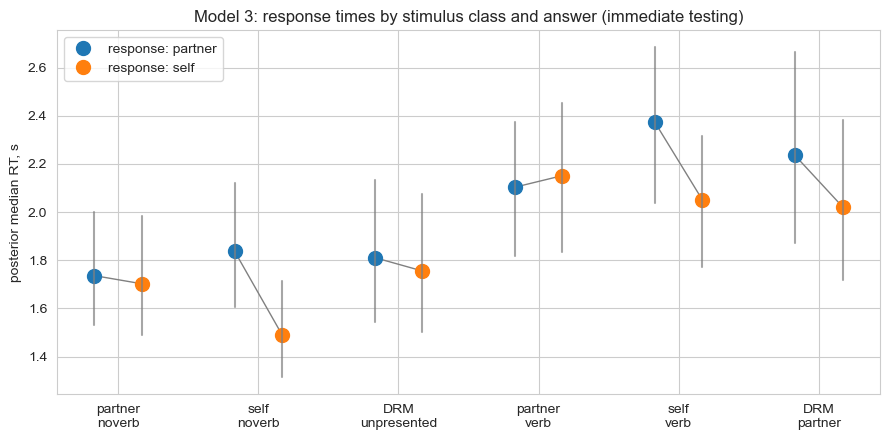

,contrast,mean_s,hdi,P(<0)
0,"self-partner RT, own words noverb (imm)",-0.347,"[-0.474, -0.229]",1.000
1,"self-partner RT, DRM unpresented (imm)",-0.057,"[-0.306, 0.195]",0.671


In [12]:
# ---- RT figure: self vs partner response speed per class (immediate) ----
p3 = idata_m3.posterior
fig, ax = plt.subplots(figsize=(9, 4.5))
for k, cls in enumerate(CLASS_ORDER):
    vp = p3[f"rt_{cls}_partner_imm"].stack(s=("chain", "draw")).values
    vs = p3[f"rt_{cls}_self_imm"].stack(s=("chain", "draw")).values
    ax.plot([k - 0.17, k + 0.17], [np.median(vp), np.median(vs)], "-", color="grey", lw=1)
    ax.plot(k - 0.17, np.median(vp), "o", ms=10, color="tab:blue", label="response: partner" if k == 0 else None)
    ax.plot(k + 0.17, np.median(vs), "o", ms=10, color="tab:orange", label="response: self" if k == 0 else None)
    for v, xx in [(vp, k - 0.17), (vs, k + 0.17)]:
        lo, hi = np.quantile(v, [0.03, 0.97])
        ax.plot([xx, xx], [lo, hi], color="grey", lw=1.5, alpha=0.7)
ax.set_xticks(range(6), CLASS_SHORT)
ax.set_ylabel("posterior median RT, s")
ax.set_title("Model 3: response times by stimulus class and answer (immediate testing)")
ax.legend()
fig.tight_layout()
save_fig(fig, "rt_by_class.png")
plt.show()

rt_c = {
    "self-partner RT, own words noverb (imm)":
        p3["rt_ordinary_self_noverb_self_imm"].stack(s=("chain", "draw")).values
        - p3["rt_ordinary_self_noverb_partner_imm"].stack(s=("chain", "draw")).values,
    "self-partner RT, DRM unpresented (imm)":
        p3["rt_critical_unpresented_self_imm"].stack(s=("chain", "draw")).values
        - p3["rt_critical_unpresented_partner_imm"].stack(s=("chain", "draw")).values,
}
pd.DataFrame([{"contrast": n, "mean_s": v.mean(),
               "hdi": np.round(np.quantile(v, [0.03, 0.97]), 3).tolist(),
               "P(<0)": (v < 0).mean()} for n, v in rt_c.items()]).round(3)

## 5. What the re-analysis says

| Question | Finding | Evidence |
|---|---|---|
| Global bias to answer "I said it"? | **No** — ordinary partner words are *denied* (P ≈ 0.28–0.44) | C2 table; consistent with the lab's Model 1 |
| DRM lure claimed above partner's words? | **Yes**, immediate and (stronger) delayed | C1, C2: P(>0) = 1.00 |
| ...above one's OWN words after a week? | **Yes** | C3 delayed: P(>0) = 1.00 |
| Lure spoken by partner still claimed? | **Yes** | C4: P(>0) = 1.00 |
| Association strength mechanism? | **Yes** — LogDice slope positive for partner's words, ~null for own | Model 2 |
| RT signature for critical trials? | Weak — fastest self-responses for own ordinary words; no stable DRM marker | Model 3 |

**Interpretation.** Cryptomnesia here is *not* a generic response bias: it is selective for
semantically central, never-uttered (or partner-uttered) lures, grows with delay, and is graded by
corpus association strength — a familiarity-misattribution mechanism operating within source
monitoring.

### Exercises
1. Add a **list-level LogDice of the lure** (crossed with interval) and test whether some DRM lists
   (море vs стул) generate stronger cryptomnesia.
2. Re-place the reference category at `critical_unpresented` and re-express all contrasts.
3. Compute a Savage–Dickey Bayes factor for `beta_logdice = 0` (prior Normal(0,1)).
4. Model accuracy instead of self-attribution for ordinary stimuli — how do interval and
   verbalization change source discrimination?
5. Fit the RT model with an ExGaussian likelihood instead of Normal — do the class effects move?

## References

* Gershkovich, V. A., & Popova, A. S. (2017). *Unconscious plagiarism in a DRM dialogue paradigm.*
  CogSci proceedings / SPbSU diploma thesis.
* Roediger, H. L., & McDermott, K. B. (1995). Creating false memories. *JEP: LMC*, 21(4), 803–814.
* Newton, E. M., & Newton, P. M. (1980). The case of the plagiarism. *Psychology of Music*.
* Brown, A. S., & Murphy, D. R. (1989). Cryptomnesia: Delineating inadvertent plagiarism.
  *JEP: LMC*, 15(3), 432–442.
* McElreath, R. (2020). *Statistical Rethinking* (2nd ed.). CRC Press.

*Data: Gershkovich lab (Popova diploma + 3 replications, N = 159).*